# Accuracy-Driven QSVT Planning

This tutorial turns a target accuracy into an auditable QSVT plan. The same finite linear system is supplied as a NumPy matrix, a PennyLane operator, and an explicit block-encoding specification. We compare degree selection, phase-synthesis fallback and caching, access-model handling, logical resources, and one executed circuit validation.

## Variable definitions

- $A$ is the finite system matrix, $b$ is the right-hand side, and $x=A^{-1}b$ is the target solution.
- $b=(1,1)^T$ uses $T$ to denote vector transpose.
- $\varepsilon$ (`tolerance`) is the requested approximation-error bound.
- $d$ (`degree`) is a candidate polynomial degree searched by the planner.
- $\alpha$ is the normalization in a block encoding of $A/\alpha$.
- `execute=True` requests finite circuit validation after planning; it is a Boolean configuration parameter.

## Planning contract

The planner searches candidate degrees until the polynomial error is below the requested tolerance. With `execute=True`, it also rejects mixed-parity polynomials that cannot be represented by one QSVT sequence, synthesizes phases using the configured solver order, selects a concrete block-encoding access model, and estimates its logical resources. A matrix fallback is useful for finite validation, but it is not a claim of scalable data access.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pennylane as qml

from qsvt.block_encoding import pennylane_operator_block_encoding_spec
from notebooks._support import display_table
from qsvt.planning import (
    QSVTExecutionConfig,
    QSVTProblemSpec,
    QSVTTransformSpec,
    plan_qsvt,
    run_qsvt_plan,
)
from qsvt.synthesis import clear_phase_synthesis_cache, phase_synthesis_cache_info

## One problem, three input forms

We solve $A x=b$ for $A=\mathrm{diag}(1,2)$ and $b=(1,1)^T$. The explicit PennyLane specification records a Pauli-LCU PrepSelPrep access model; the raw matrix and raw operator intentionally leave access selection to the planner.


In [2]:
matrix = np.diag([1.0, 2.0])
operator = qml.dot([1.5, -0.5], [qml.I(0), qml.Z(0)])
operator_spec = pennylane_operator_block_encoding_spec(
    operator,
    encoding_wires=[1],
    block_encoding="prepselprep",
)
rhs = np.ones(2)
population_zero = np.diag([1.0, 0.0])

inputs = [
    ("NumPy matrix", matrix),
    ("PennyLane operator", operator),
    ("BlockEncodingSpec", operator_spec),
]
assert np.allclose(qml.matrix(operator, wire_order=[0]), matrix)

## Search by tolerance, then synthesize and cost

The requested degree sequence is 3, 5, 7, 9. Degree 7 is the first candidate that is both accurate enough and single-sequence realizable. Repeating the same transform across input forms also exposes the phase cache: identical synthesized polynomials are reused instead of solved again.


In [3]:
transform = QSVTTransformSpec(
    "linear_system",
    tolerance=0.4,
    min_degree=3,
    max_degree=9,
    degree_step=2,
    parameters={"num_points": 201, "bounded_num_points": 401},
)
execution_config = QSVTExecutionConfig(
    execute=True,
    angle_solvers=("root-finding", "iterative"),
    reconstruction_num_points=65,
)

clear_phase_synthesis_cache()
plans = []
for label, source in inputs:
    problem = QSVTProblemSpec(
        source,
        rhs=rhs,
        observables={"population_0": population_zero},
        name=label,
    )
    plans.append(plan_qsvt(problem, transform, execution_config))

cache_info = phase_synthesis_cache_info()
plan_rows = [
    {
        "input": label,
        "kind": plan.input_kind,
        "degree": plan.selected_degree,
        "error": plan.achieved_error,
        "access": plan.access_model_status,
        "model": plan.resource_estimates[0][1].estimator_model,
        "ready": plan.execution_ready,
    }
    for (label, _), plan in zip(inputs, plans, strict=True)
]
display_table(
    "Accuracy-driven plans",
    plan_rows,
    [
        ("input", lambda row: row["input"]),
        ("input kind", lambda row: row["kind"]),
        ("degree", lambda row: row["degree"]),
        ("polynomial error", lambda row: row["error"]),
        ("access status", lambda row: row["access"]),
        ("resource model", lambda row: row["model"]),
        ("execution ready", lambda row: row["ready"]),
    ],
    layout="rows",
)
print(f"phase cache: {cache_info}")

Accuracy-driven plans
---------------------
input               input kind                         degree  polynomial error  access status          resource model                    execution ready
------------------  ---------------------------------  ------  ----------------  ---------------------  --------------------------------  ---------------
NumPy matrix        finite-matrix                      7       0.07202           matrix-fallback        arbitrary-unitary-block-encoding  True           
PennyLane operator  pennylane-operator                 7       0.07202           matrix-fallback        arbitrary-unitary-block-encoding  True           
BlockEncodingSpec   block-encoding:pennylane-operator  7       0.07202           provided-access-model  pauli-lcu-qubitization            True           
phase cache: {'size': 2, 'hits': 4, 'misses': 2}


Degree candidates for the matrix input
--------------------------------------
requested degree  error    single sequence  selected
----------------  -------  ---------------  --------
3                 0.1335   False            False   
5                 0.1046   False            False   
7                 0.07202  True             True    


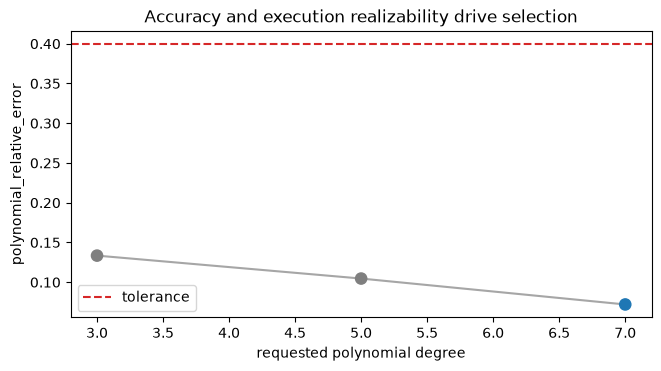

In [4]:
candidate_rows = [
    {
        "degree": candidate.requested_degree,
        "error": candidate.error,
        "single_sequence": candidate.metadata.get("single_sequence_realizable"),
        "selected": candidate.requested_degree == plans[0].selected_degree,
    }
    for candidate in plans[0].degree_candidates
]
display_table(
    "Degree candidates for the matrix input",
    candidate_rows,
    [
        ("requested degree", lambda row: row["degree"]),
        ("error", lambda row: row["error"]),
        ("single sequence", lambda row: row["single_sequence"]),
        ("selected", lambda row: row["selected"]),
    ],
    layout="rows",
)

degrees = [row["degree"] for row in candidate_rows]
errors = [row["error"] for row in candidate_rows]
colors = ["tab:blue" if row["single_sequence"] else "tab:gray" for row in candidate_rows]
fig, ax = plt.subplots(figsize=(6.5, 3.6), constrained_layout=True)
ax.scatter(degrees, errors, c=colors, s=65)
ax.plot(degrees, errors, color="0.65", zorder=0)
ax.axhline(transform.tolerance, color="tab:red", linestyle="--", label="tolerance")
ax.set_xlabel("requested polynomial degree")
ax.set_ylabel(plans[0].error_metric)
ax.set_title("Accuracy and execution realizability drive selection")
ax.legend()
plt.show()

## Execute the selected validation circuit

The finite matrix plan is executed on a simulator. Its error ledger separates the polynomial approximation from phase reconstruction and circuit-versus-polynomial agreement. State preparation, postselection or amplitude amplification, scalable oracle construction, and full-vector readout remain outside this validation circuit.


In [5]:
run = run_qsvt_plan(plans[0])
synthesis = plans[0].synthesis_results[0][1]
execution = run.executions[0][1]

ledger_rows = [{"component": key, "error": value} for key, value in run.error_budget.items()]
display_table(
    "Executed error ledger",
    ledger_rows,
    [("component", lambda row: row["component"]), ("error", lambda row: row["error"])],
    layout="rows",
)
print(f"phase solver: {synthesis.angle_solver}")
print(f"phase reconstruction max error: {synthesis.reconstruction_max_error:.3e}")
print(f"circuit logical-output relative error: {execution.logical_output_relative_error:.3e}")
print(f"population_0 (circuit): {run.observables['coeffs:population_0']['circuit']:.6f}")

Executed error ledger
---------------------
component                        error   
-------------------------------  --------
workflow_approximation_error     0.07202 
phase_reconstruction_error       6.02e-08
circuit_vs_polynomial_error      3.35e-08
maximum_sampling_standard_error  n/a     
additive_error_proxy             0.07202 
phase solver: iterative
phase reconstruction max error: 6.018e-08
circuit logical-output relative error: 3.351e-08
population_0 (circuit): 0.745669


## Validation

These checks make the tutorial fail if input equivalence, accuracy-driven selection, access-model preservation, caching, or circuit agreement regresses.


In [6]:
assert all(plan.selected_degree == 7 for plan in plans)
assert all(plan.met_tolerance and plan.execution_ready for plan in plans)
assert plans[0].access_model_status == "matrix-fallback"
assert plans[1].access_model_status == "matrix-fallback"
assert plans[2].access_model_status == "provided-access-model"
assert cache_info["hits"] > 0 and cache_info["misses"] > 0
assert run.succeeded
assert execution.logical_output_relative_error < 1e-6
print("validation: passed")

validation: passed
